### Notebook 9: Inter-group scaling 

Once we make stacks from various groups of LFEs, we may want to compare those stacks.  Here we take one approach; we calculate coefficients that map one stack to another. 

In [13]:
import numpy as np
import os
import matplotlib.pyplot as plt

import os,sys
sys.path.append(os.path.join(os.environ['PYFILES']))
import LFEAnalysis as lfeanalysis
lfeanalysis.reload_all(lfeanalysis)

### 1. Load and prepare the data

As usual, we first read in detections and the data.

In [14]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfeanalyse(fnum=156,catalog='Bostock',region='Cascadia')

# and read the relevant detections
lf.read_detection_info()

# load the data
lf.read_data()

In [15]:
# normalise the seismograms
lf.normalize_data(single_norm=False)

# we may first need to discard any LFE intervals that contain NaNs, 
# as these will disrupt the filtering
lf.discard_data_with_nans()

# and bandpass filter
# we can filter the intervals with a 2-pass (non-causal) butterworth filter
# let's choose corners of 1 and 10 Hz
lf.filter_data(flm=[1,10])

### 2. Group events by time

Next, we want to identify the slow slip events and group the LFEs in this family by their time in the event.

In [16]:
# identify the times of large SSEs
lf.identify_sse_times(n_events=10)

# here, compute the number of LFEs per 5-hour period
lf.compute_lfe_rates(bin_duration=5*3600)

# to do so, we first determine a family "start time": 
# here the time when the LFE rate reaches half the maximum LFE rate
lf.select_start_times(start_rate=0.5)

# and then group the events by time since the start time
# here we have two groups: 0-0.75 days since the start time and 0.75-3 days since the start time
lf.group_events_bytime(tsplits=[0,0.75,3])

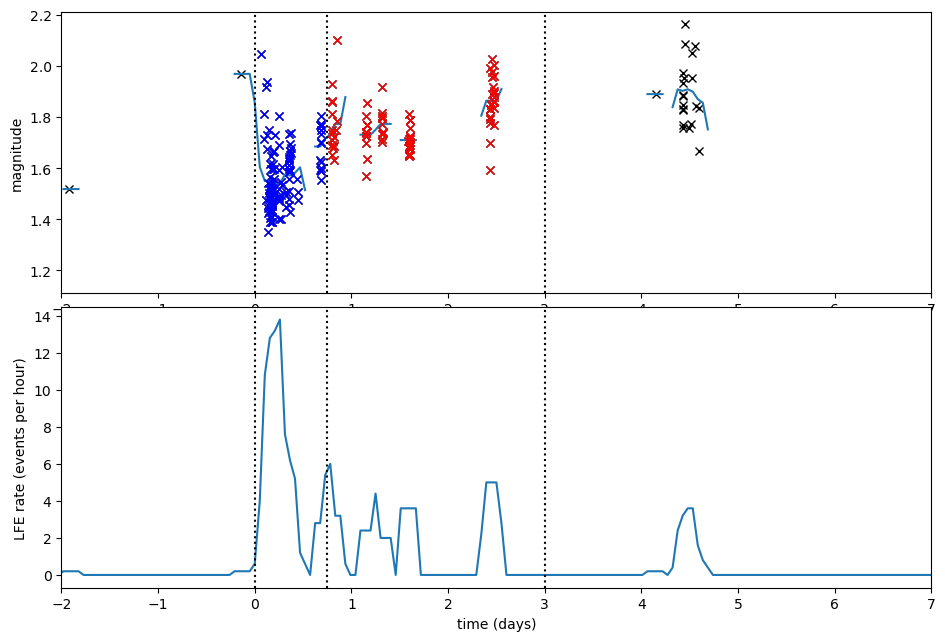

In [17]:
# it may be useful to plot the LFE properties and the LFE rate through time during an SSE
lf.plot_rate(iev=2003)

### 2. Stack

In [18]:
# stack for each group
lf.stack_by_group()

# and pick arrival times
lf.pick_stacks(minsnr=10)

/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_stacking.py:462: RuntimeWarning: invalid value encountered in multiply
  self.grpstkb[ky][idi]=np.ndarray([nvl,Nboot])*float('nan')
/Users/jessicahawthorne/PYFILES/LFEAnalysis/_lfe_stacking.py:465: RuntimeWarning: invalid value encountered in multiply
  self.totstkb[idi]=np.ndarray([nvl,Nboot])*float('nan')


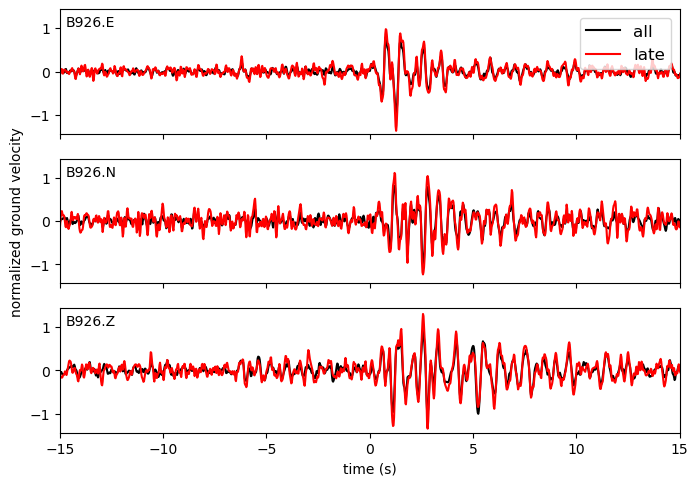

In [19]:
# and we could compare some of the stacks
p=lf.plot_stacks(stype='all',Ns=1,stn='B926',morestacks=['late'])

### 3. Read in information about the station locations

We need this because we'll want to project the ground velocities along and perpendicular to the ray paths.

In [53]:
# read the station locations
lf.read_station_locations()

# and compute the station location relative to the LFE family we're working with
print('\nLFE longitude, latitude, depth (in km)',lf.floc)
lf.relative_station_locations()

# and then compute the takeoff angle per station
lf.find_takeoff_angles()

ky='B926'
print('\nStation {:s} is located {:0.0f} km from the LFE, horizontally'.format(ky,lf.statdst[ky]))
print('It is at azimuth {:0.0f} from the LFE'.format(lf.stataz[ky]))

Reading station info from directory /Users/jessicahawthorne/DATA/LFEAnalysis/Cascadia/Family156

LFE longitude, latitude, depth (in km) [-123.6187   48.5193   36.96  ]


/Users/jessicahawthorne/miniconda3/envs/lfeanalysis/lib/python3.13/site-packages/obspy/core/inventory/network.py:321: UserWarning: Found more than one matching channel metadata. Returning first.
  warnings.warn(msg)



Station B926 is located 50 km from the LFE, horizontally
It is at azimuth 312 from the LFE


### 3. Compute scalings between the stacks

We now want to compute the scalings between stacks of events with different groups of LFEs, obtaining scaling factors such that

$$ \textrm{grouped stack } = \textrm{ scaling factor } \times \textrm{ average stack }$$

The function lf.compute_scalings computes these scaling using a wlen-long interval starting at time marker t0.  It computes how much you would have to multiply the average stack (lf.totstk) by to recover the grouped stack (lf.grpstk), employing a cross-correlation approach.

There are two sets of scaling factors.  One is per station, averaging over components (lf.scalings), and the other is per component (lf.scalingsc).  We're mostly interested in how the scaling factors vary with component, so the scaling factors per component have been divided by the scaling computed per station.

In [38]:
 now we can compute scalings between the stacks
lf.compute_scalings(wlen=[0,4])

# the scalings between the average and the groups, as averaged over components are here
print('Scalings per station:\n',lf.scalings)

# and the scalings computed per component are here
# R indicates the radial component
# T indicates the transverse component
print('\nScalings per component, divided by station average:\n',lf.scalingsc)

Scalings per station:
 {'early': {np.str_('B926'): np.float64(0.8714523884424374), np.str_('KHVB'): np.float64(0.6735898378970753), np.str_('LZB'): np.float64(0.9126147408818335), np.str_('MGCB'): np.float64(0.802615347560268), np.str_('NLLB'): np.float64(1.0091551201477518), np.str_('PGC'): np.float64(0.930701056525093), np.str_('SHDB'): np.float64(0.9479745844800055), np.str_('SHVB'): np.float64(0.9224278814193603), np.str_('YOUB'): np.float64(0.8191296127647786)}, 'late': {np.str_('B926'): np.float64(1.3010102994372372), np.str_('KHVB'): np.float64(1.2318463101033372), np.str_('LZB'): np.float64(1.2562017297215011), np.str_('MGCB'): np.float64(1.176451169393417), np.str_('NLLB'): np.float64(1.218432833505198), np.str_('PGC'): np.float64(1.1773710794983967), np.str_('SHDB'): np.float64(1.0748583271282626), np.str_('SHVB'): np.float64(1.1071684650730238), np.str_('YOUB'): np.float64(1.3457271400502187)}}

Scalings per component, divided by station average:
 {'early': {np.str_('B926'):

Scaling factor for station MGCB: 0.803


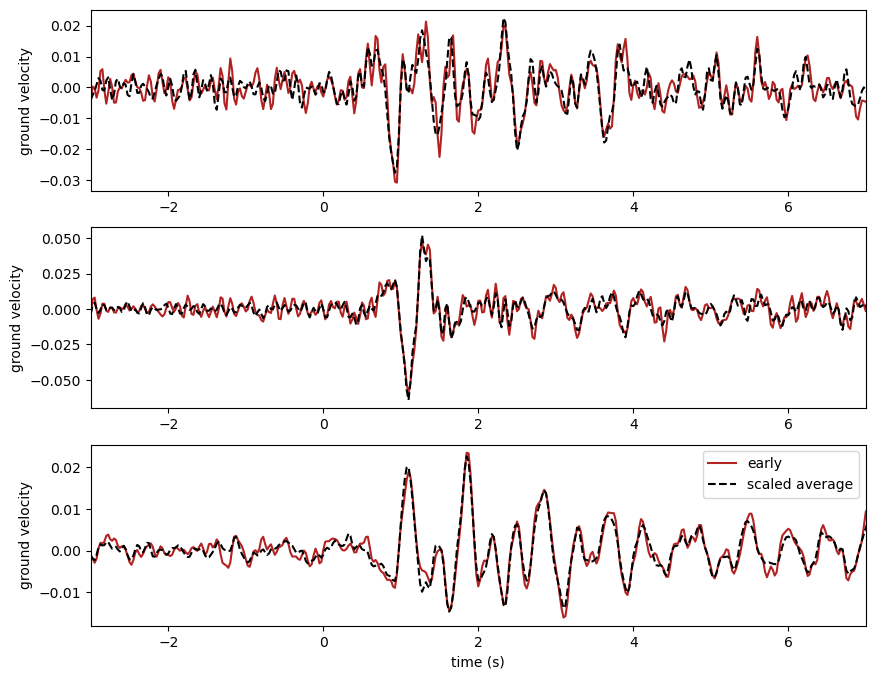

In [40]:
# let's check that the scaling seems sensible: one per station
stn='MGCB'
chns=['E','N','Z']
Nc=len(chns)

f=plt.figure(figsize=(10,8))
for kc in range(0,Nc):
    chn=chns[kc]
    ph=plt.subplot(Nc,1,kc+1)
    # the early stack
    tre=lf.grpstk['early'].select(station=stn,channel=chn)[0]    
    trt=lf.totstk.select(station=stn,channel=chn)[0]

    # plot
    he,=ph.plot(trt.times()-trt.stats.t0,tre.data,
             color='firebrick',linestyle='-',label='early')
    hs,=ph.plot(trt.times()-trt.stats.t0,trt.data*lf.scalings['early'][stn],
             color='k',linestyle='--',label='scaled average')
    ph.set_xlim([-3,7])
    ph.set_ylabel('ground velocity');
    
ph.set_xlabel('time (s)');
ph.legend();

print('Scaling factor for station {:s}: {:0.3f}'.format(stn,lf.scalings['early'][stn]))

Scaling factor adjustment for MGCB.E: 0.955
Scaling factor adjustment for MGCB.N: 1.018
Scaling factor adjustment for MGCB.Z: 0.999
Scaling factor for station MGCB: 0.803


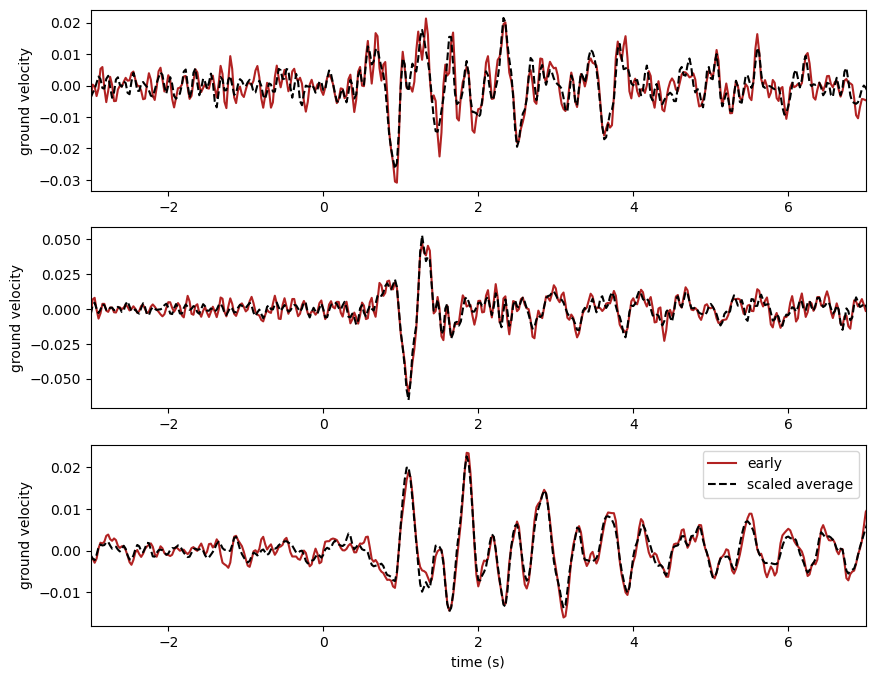

In [51]:
# let's check that the scaling seems sensible: one per component
stn='MGCB'
chns=['E','N','Z']
Nc=len(chns)

# the

f=plt.figure(figsize=(10,8))
for kc in range(0,Nc):
    chn=chns[kc]
    ph=plt.subplot(Nc,1,kc+1)
    # the early stack
    tre=lf.grpstk['early'].select(station=stn,channel=chn)[0]    
    trt=lf.totstk.select(station=stn,channel=chn)[0]

    # plot
    scl=lf.scalingsc['early'][stn][chn]*lf.scalings['early'][stn]
    ph.plot(trt.times()-trt.stats.t0,tre.data,
             color='firebrick',linestyle='-',label='early')
    ph.plot(trt.times()-trt.stats.t0,trt.data*scl,
             color='k',linestyle='--',label='scaled average')
    ph.set_xlim([-3,7])
    ph.set_ylabel('ground velocity');
    
    print('Scaling factor adjustment for {:s}.{:s}: {:0.3f}'.format(stn,chn,lf.scalingsc['early'][stn][chn]))
    
ph.set_xlabel('time (s)');
ph.legend();

print('Scaling factor for station {:s}: {:0.3f}'.format(stn,lf.scalings['early'][stn]))

### 4. Note bootstrapped scalings

We also redo this scaling analysis with the bootstrapped stacks.

In [50]:
# the bootstrapped per-station scalings are here
# there is now a list of scalings per station
stn='B926'
print('The per-station bootstrapped scalings are in lf.scalingsb, with one key per group:\n',lf.scalingsb.keys())
print('And within those items are dictionaries for the stations, with keys:\n',np.array(list(lf.scalingsb['early'].keys())))
print('And then one scaling per bootstrapped stack:\n',lf.scalingsb['early'][stn])

# and likewise the per-component scalings are here
# again with a list of scalings per component
print('\nThe per-component bootstrapped scalings are in lf.scalingscb, with one key per group:\n',lf.scalingscb.keys())
print('And within those items are dictionaries for the stations, with keys:\n',np.array(list(lf.scalingscb['early'].keys())))
print('And then one set of scalings per component:\n',lf.scalingscb['early'][stn])

print('\nBut recall that the per-component scalings have been normalised by the per-station scalings')
print('So that the full per-component scalings is lf.scalingscb * lf.scalingsb');
print('And the radial and transverse scalings could also be modified by normalisation, as noted below')

The per-station bootstrapped scalings are in lf.scalingsb, with one key per group:
 dict_keys(['early', 'late'])
And within those items are dictionaries for the stations, with keys:
 ['B926' 'KHVB' 'LZB' 'MGCB' 'NLLB' 'PGC' 'SHDB' 'SHVB' 'YOUB']
And then one scaling per bootstrapped stack:
 [0.90525777 0.89289776 0.82383625 0.86793973 0.9005584  0.90185981
 0.92088269 0.87304088 0.88771758 0.87359699]

The per-component bootstrapped scalings are in lf.scalingscb, with one key per group:
 dict_keys(['early', 'late'])
And within those items are dictionaries for the stations, with keys:
 ['B926' 'KHVB' 'LZB' 'MGCB' 'NLLB' 'PGC' 'SHDB' 'SHVB' 'YOUB']
And then one set of scalings per component:
 {'E': array([1.02591864, 1.04168706, 1.03186617, 0.99121677, 1.05358405,
       1.02992576, 0.99748499, 1.03406059, 1.00110218, 1.06967684]), 'N': array([1.03110617, 0.99640968, 0.9376388 , 1.04861806, 0.9875342 ,
       1.04729948, 0.96451749, 0.96709528, 1.08206937, 0.96773887]), 'Z': array([0.899

### 5. Normalize the energy between the transverse and radial components

We are mostly interested in whether the early and late stacks are scaled-up more on the radial or  transverse components.

We can just compare these numbers and ask which is bigger: the radial scaling $A_r$ or the transverse scaling $A_t$.  But since we'll want to compare between the early and late stacks, it makes sense to normalize somehow to decide how much bigger.  So we'll compute the normalized scalings

$$A_r' = \frac{A_r}{\sqrt{2(A_r^2+A_t^2)}}$$

$$A_t' = \frac{A_t}{\sqrt{2(A_r^2+A_t^2)}}$$

where the factor of 2 is just so that the scalings always stay close to 1.

In [47]:
# let's have a look at the radial and transverse scalings for the late stack on one station
stn=list(lf.scalingsc['late'].keys())[1]
scls=lf.scalingsc['late'][stn]

print('Radial scaling at station {:s}: {:0.03}'.format(ky,scls['R']))
print('Transverse scaling at station {:s}: {:0.03}'.format(ky,scls['T']))

Radial scaling at station B926: 0.982
Transverse scaling at station B926: 1.02


In [48]:
# the total amplitude, across components
totscl=np.sqrt((scls['R']**2+scls['T']**2)/2)
print(totscl)

print('Normalized radial scaling at station {:s}: {:0.03}'.format(ky,scls['R']/totscl))
print('Normalized transverse scaling at station {:s}: {:0.03}'.format(ky,scls['T']/totscl))

0.9999999999999999
Normalized radial scaling at station B926: 0.982
Normalized transverse scaling at station B926: 1.02


In [46]:
# let's go ahead and normalize the radial and transverse scalings for all stations
lf.normalize_radtrans_scaling()

scls=lf.scalingsc['early'][stn]
print('Normalized early radial scaling at station {:s}: {:0.03}'.format(ky,scls['R']))
print('Normalized early transverse scaling at station {:s}: {:0.03}'.format(ky,scls['T']))

scls=lf.scalingsc['late'][stn]
print('\nNormalized late radial scaling at station {:s}: {:0.03}'.format(ky,scls['R']))
print('Normalized late transverse scaling at station {:s}: {:0.03}'.format(ky,scls['T']))

Normalized early radial scaling at station B926: 1.03
Normalized early transverse scaling at station B926: 0.969

Normalized late radial scaling at station B926: 0.982
Normalized late transverse scaling at station B926: 1.02


### 6. Plot the scalings by location

We now have a set of scalings on the radial and transverse for each component, for the early and late stacks.
We may wish to examine how these the radial and transverse components change from the early stack to the later stack, as a function of station location.

Though normally the accuracy of the scalings is low enough that these plots just show noise.

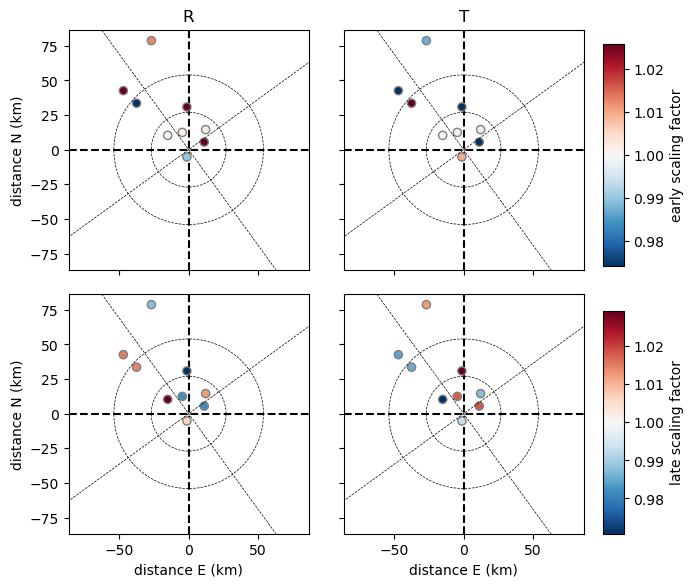

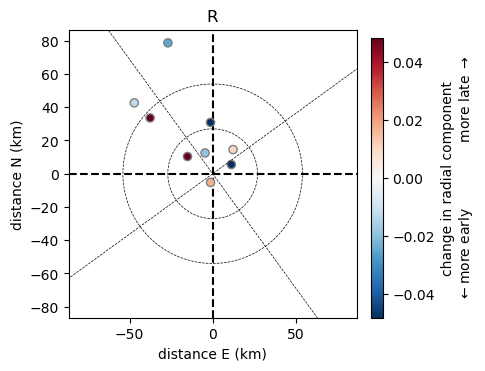

In [76]:
# we can plot the radial and transverse scaling factors for the early and late components
# these two are inversely related to each other, as we've just normalised by the total energy in these components
# lines are plotted in the plate convergence direction and perpendicular to convergence
lf.plot_scaling_by_location(cplot=['R','T'],grps=['early','late'])

# or we can plot the change in the radial scaling from early to late
lf.plot_scaling_by_location(cplot=['R'],grps=['late - early'])